Используйте базу трафика с сайта компании.

Напишите модель для прогнозирования трафика.

При параметре `length = 60`, добейтесь максимально точного соответствия между графиками корреляции исходного сигнала и прогноза.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gdown

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.optimizers import Adam

DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l11/traff.csv'
DATA_FILE = 'traff.csv'


def load_traffic_table(url=DATA_URL, file_name=DATA_FILE):
    # Таблица: дата и значение трафика
    gdown.download(url, file_name, quiet=True)

    traffic_df = pd.read_csv(
        file_name,
        header=None,
        names=['date', 'value'],
        sep=',',
        thousands=','
    )

    # Удаляем пропуски
    traffic_df = traffic_df.dropna().reset_index(drop=True)
    return traffic_df


def prepare_scaled_series(frame):
    # Для обучения используется только числовой столбец value
    values = frame['value'].values.reshape(-1, 1)

    # LSTM лучше обучается на нормализованных значениях
    fitted_scaler = MinMaxScaler()
    scaled = fitted_scaler.fit_transform(values)

    return values, scaled, fitted_scaler


df = load_traffic_table()
data, data_scaled, scaler = prepare_scaled_series(df)

# Размер окна
win_len = 5

# Размер пакета при обучении
batch_size = 32

train_len = int(len(data_scaled) * 0.9)

train_gen = TimeseriesGenerator(
    data_scaled,
    data_scaled,
    length=win_len,
    batch_size=batch_size,
    end_index=train_len
)

test_gen = TimeseriesGenerator(
    data_scaled,
    data_scaled,
    length=win_len,
    batch_size=batch_size,
    start_index=train_len
)


In [2]:
def build_lstm_forecaster(window_size, learning_rate=1e-3):
    # Первая LSTM возвращает последовательность
    network = Sequential([
        LSTM(128, input_shape=(window_size, 1), return_sequences=True),
        Dropout(0.2),

        LSTM(64, return_sequences=False),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dense(1)
    ])

    # В задаче регрессии прогнозируем числовое значение
    network.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse'
    )

    return network


model = build_lstm_forecaster(win_len)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=test_gen,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 6s 65ms/step - loss: 0.0340 - val_loss: 0.0339
Epoch 2/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0089 - val_loss: 0.0157
Epoch 3/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0073 - val_loss: 0.0189
Epoch 4/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0150
Epoch 5/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0148
Epoch 6/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0066 - val_loss: 0.0284
Epoch 7/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0068 - val_loss: 0.0169
Epoch 8/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0152
Epoch 9/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0059 - val_loss: 0.0165
Epoch 10/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0060 - val_loss: 0.0151
Epoch 11/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0061 - val_loss: 0.0146
Epoch 12/30
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0063 - val_l

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


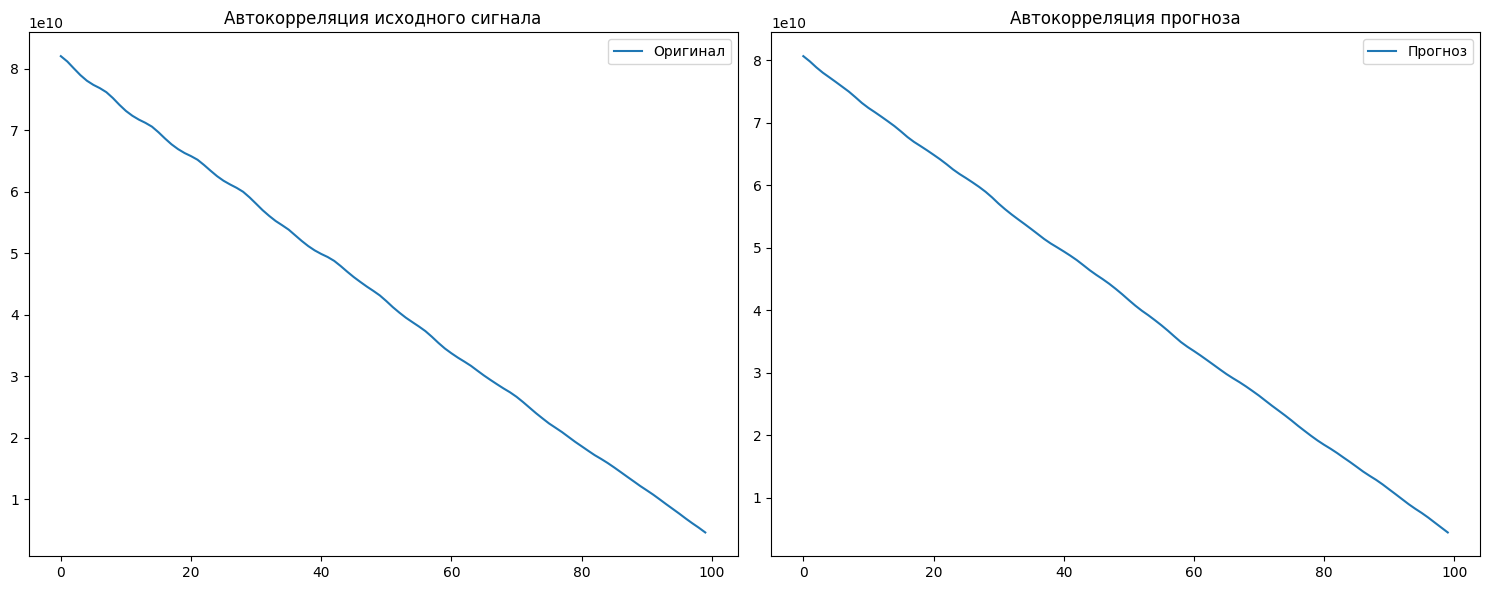

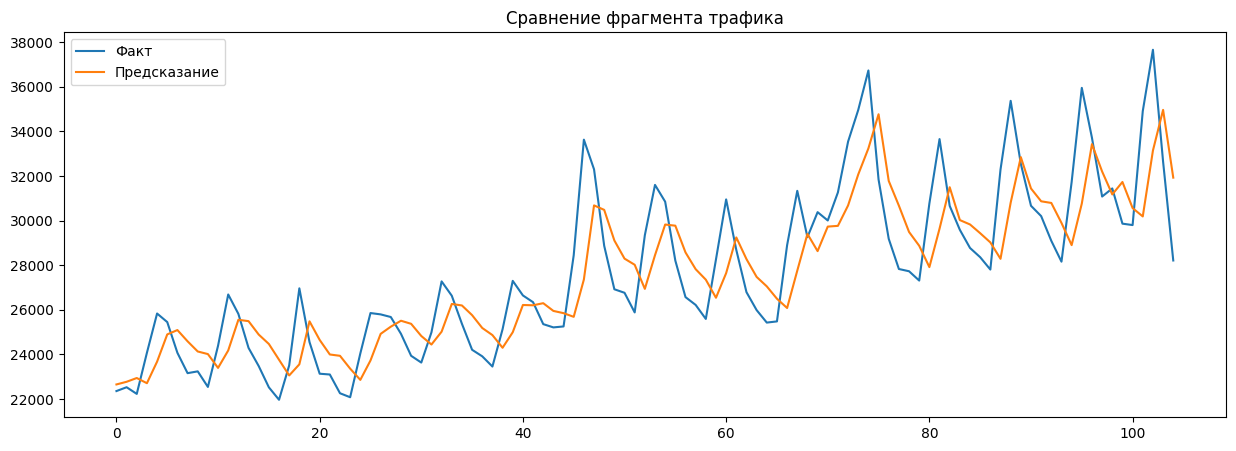

In [3]:
def restore_scale(scaled_prediction, fitted_scaler):
    # Возвращаем прогноз из масштаба
    return fitted_scaler.inverse_transform(scaled_prediction)


def calc_autocorrelation(series):
    # Автокорреляция показывает
    one_dim_series = np.asarray(series).reshape(-1)
    correlation = np.correlate(one_dim_series, one_dim_series, mode='full')
    return correlation[correlation.size // 2:]


def draw_autocorrelation_comparison(real_values, predicted_values, points=100):
    # Сравниваем автокорреляцию настоящего ряда и ряда
    plt.figure(figsize=(15, 6))

    plt.subplot(1, 2, 1)
    plt.plot(calc_autocorrelation(real_values)[:points], label='Оригинал')
    plt.title('Автокорреляция исходного сигнала')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(calc_autocorrelation(predicted_values)[:points], label='Прогноз')
    plt.title('Автокорреляция прогноза')
    plt.legend()

    plt.tight_layout()
    plt.show()


def draw_forecast_part(real_values, predicted_values, points=200):
    # Отдельно выводим небольшой участок ряда
    plt.figure(figsize=(15, 5))
    plt.plot(real_values[:points], label='Факт')
    plt.plot(predicted_values[:points], label='Предсказание')
    plt.title('Сравнение фрагмента трафика')
    plt.legend()
    plt.show()


predictions = model.predict(test_gen)

y_pred = restore_scale(predictions, scaler)
y_true = data[train_len + win_len:]

draw_autocorrelation_comparison(y_true, y_pred)
draw_forecast_part(y_true, y_pred)


In [4]:

has_nan_values = np.isnan(data_scaled).any()
print("Есть ли пустые значения в данных:", has_nan_values)


Есть ли пустые значения в данных: False
